#Análise Exploratória de Dados (EDA)

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

df = pd.read_csv('/content/drive/MyDrive/credit_risk_dataset.csv')

In [3]:
display(df.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
display(df.describe())
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Linhas: 32581
Colunas: 12


In [5]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


None

In [45]:
#df.isnull().sum()
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [7]:
display(df.dtypes)

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


##Gráficos

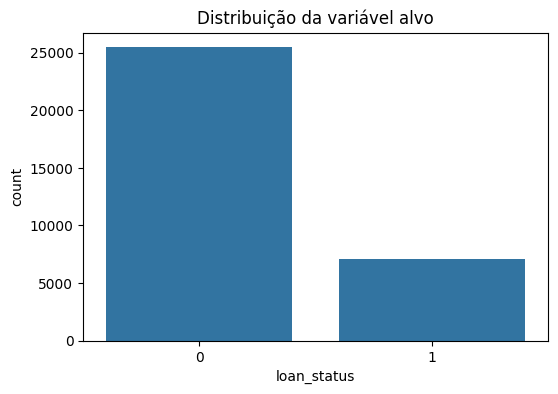

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='loan_status')
plt.title("Distribuição da variável alvo")
plt.show()
#Observa-se que a variável alvo apresenta desbalanceamento entre clientes inadimplentes e adimplentes.
#Esse comportamento pode prejudicar algoritmos supervisionados, tornando necessária a aplicação de técnicas de balanceamento na etapa de preparação dos dados.

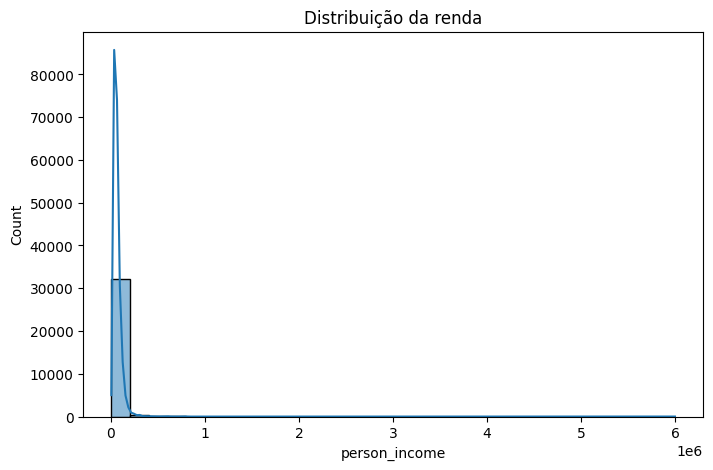

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["person_income"], bins=30,kde=True)
plt.title("Distribuição da renda")
plt.show()

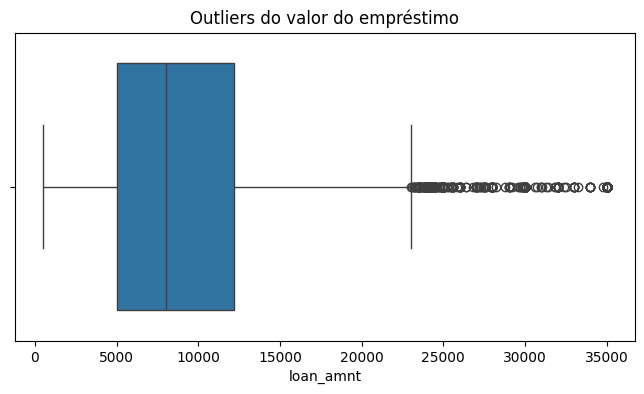

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["loan_amnt"])
plt.title("Outliers do valor do empréstimo")
plt.show()
#Esse gráfico será utilizado na Fase 2 para justificar o tratamento de outliers.

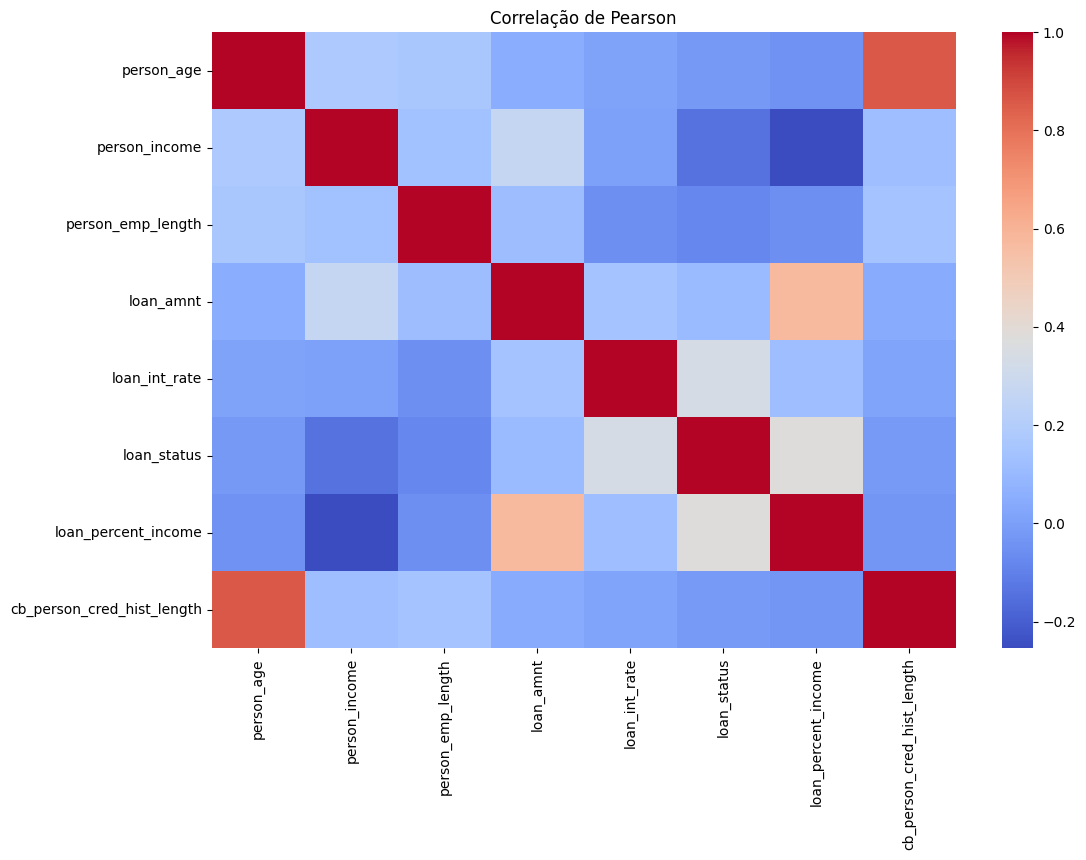

In [11]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlação de Pearson")
plt.show()

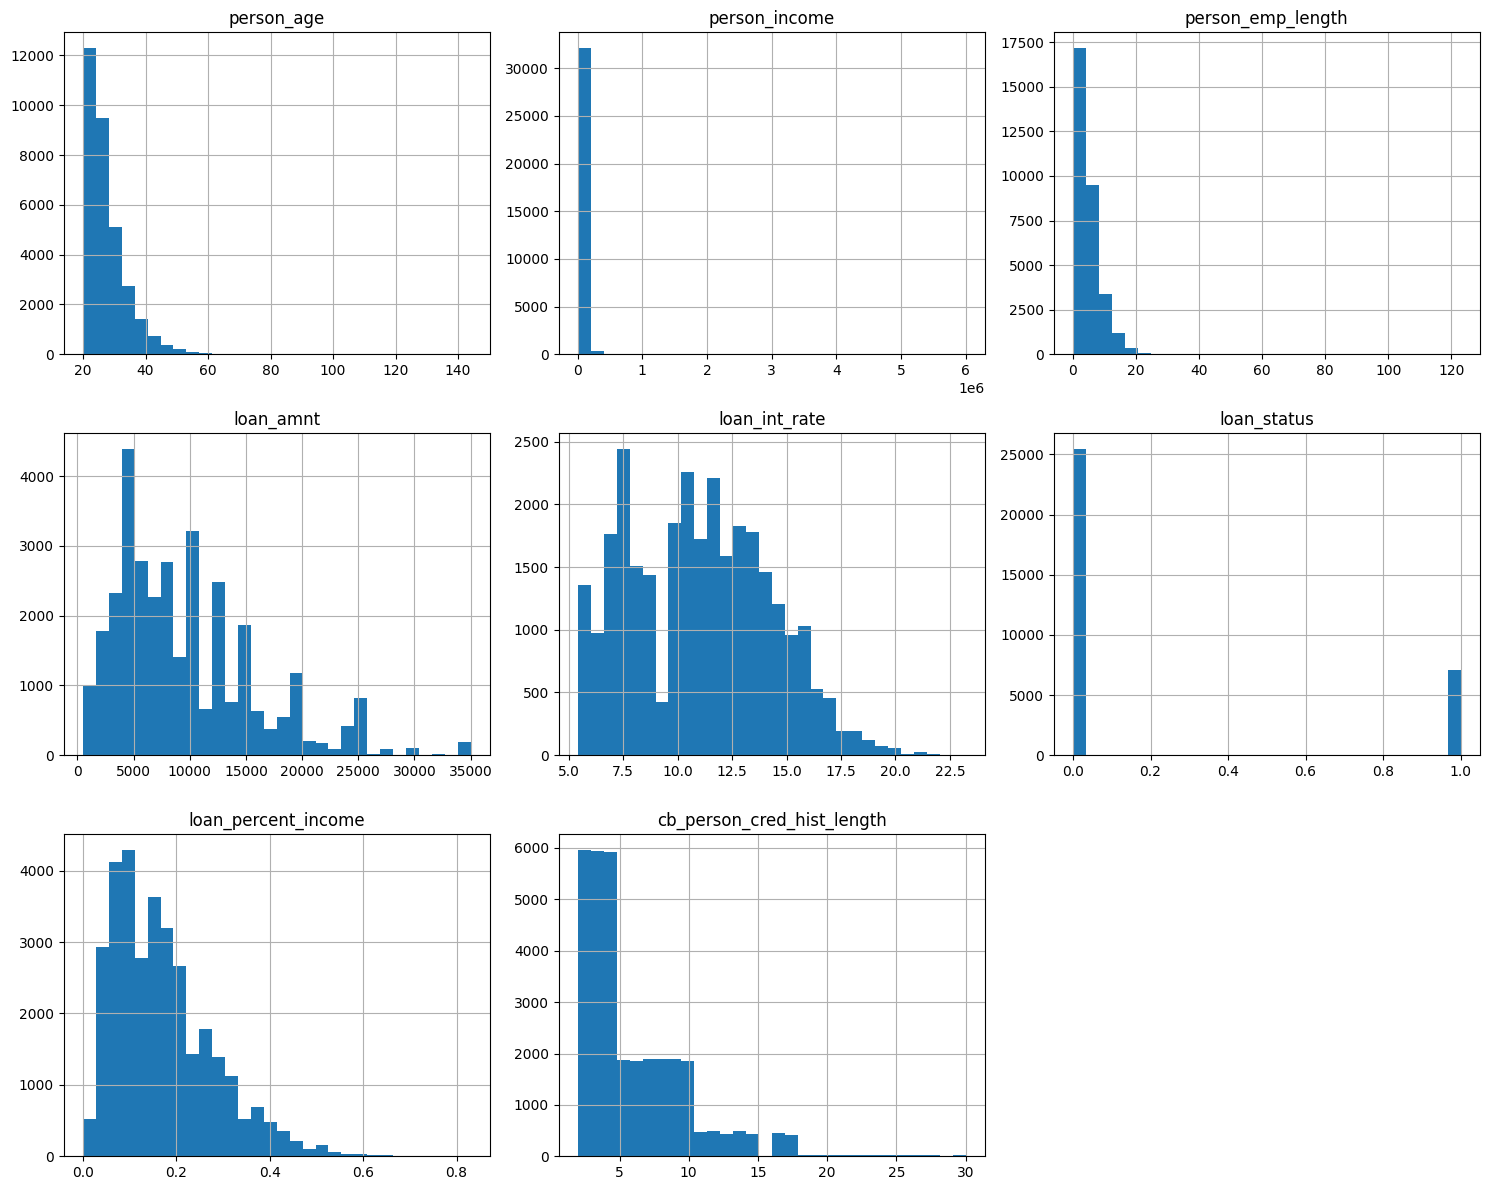

In [12]:
df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()
#Distribuição das variáveis numéricas

A análise exploratória revelou a estrutura da base de dados, permitindo identificar os tipos das variáveis, a existência de valores ausentes e possíveis registros duplicados. A inspeção gráfica mostrou indícios de desbalanceamento na variável alvo e a presença de valores extremos em algumas variáveis numéricas, como renda e valor do empréstimo. O mapa de correlação indicou relações lineares moderadas entre algumas características, sem evidências iniciais de multicolinearidade severa. Essas observações orientarão as próximas etapas de tratamento dos dados, criação de atributos e treinamento dos modelos preditivos.

#Tratamento e Limpeza (Data Prep)

In [13]:
# ===========================================
# Remoção de linhas duplicadas
# ===========================================

print(f'Quantidade de linhas duplicadas: {df.duplicated().sum()}')

df = df.drop_duplicates()

print(f'Novo tamanho da base: {df.shape}')

# ===========================================
# Separação das colunas
# ===========================================

colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = df.select_dtypes(include=['object']).columns

# ===========================================
# Tratamento dos valores nulos
# ===========================================

# Variáveis numéricas
for coluna in colunas_numericas:
    df[coluna] = df[coluna].fillna(df[coluna].median())

# Variáveis categóricas
for coluna in colunas_categoricas:
    df[coluna] = df[coluna].fillna(df[coluna].mode()[0])

# ===========================================
# Conferência
# ===========================================

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

print("\nTotal de valores ausentes:")
print(df.isnull().sum().sum())

Quantidade de linhas duplicadas: 165
Novo tamanho da base: (32416, 12)

Valores ausentes por coluna:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Total de valores ausentes:
0


In [14]:
#Tratamento de Outliers
#Vamos utilizar o método do IQR (Intervalo Interquartil).

def remover_outliers_iqr(dataframe, coluna):
    Q1 = dataframe[coluna].quantile(0.25)
    Q3 = dataframe[coluna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return dataframe[
        (dataframe[coluna] >= limite_inferior) &
        (dataframe[coluna] <= limite_superior)
    ]

In [15]:
#Aplicar somente às variáveis contínuas:
colunas_outliers = [
    'person_income',
    'loan_amnt',
    'person_emp_length'
]

for coluna in colunas_outliers:
    df = remover_outliers_iqr(df, coluna)

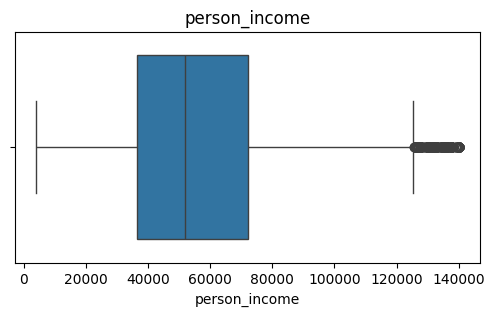

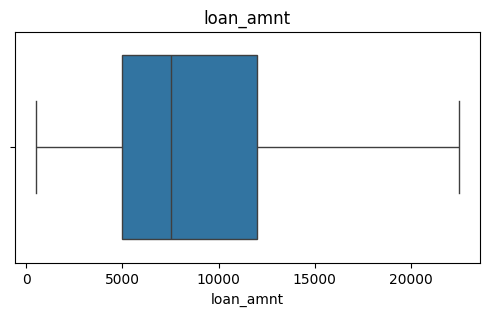

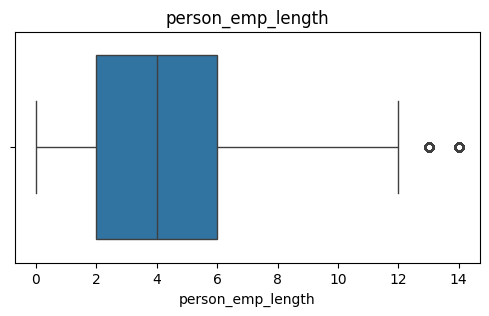

In [16]:
#Verificando novamente
for coluna in colunas_outliers:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[coluna])
    plt.title(coluna)
    plt.show()

In [17]:
#Conferência Final
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

print("\nValores ausentes:")
print(df.isnull().sum().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

Linhas: 28882
Colunas: 12

Valores ausentes:
0

Duplicados:
0


Os outliers foram identificados por meio do método do Intervalo Interquartil (IQR). Como o algoritmo KNN é altamente sensível às distâncias entre observações, a remoção dos valores extremos contribui para reduzir distorções durante o cálculo das distâncias euclidianas. Já a Árvore de Decisão é naturalmente mais robusta a outliers, mas a padronização do conjunto de dados beneficia a comparação entre os modelos.

# Feature Engineering

In [18]:
#Antes de criar a nova coluna, devemos garantir que não existam rendas iguais a zero.
print("Rendas iguais a zero:", (df['person_income'] == 0).sum())
#Caso exista alguma:
df = df[df['person_income'] > 0]

#Criando a nova variável
df['comprometimento_renda'] = (df['loan_amnt'] / df['person_income']) * 100

display(df.head())

Rendas iguais a zero: 0


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,comprometimento_renda
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,10.416667
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,57.291667
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,25.252525
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3,16.000000
11,21,10000,OWN,2.0,HOMEIMPROVEMENT,A,4500,8.63,1,0.45,N,2,45.000000


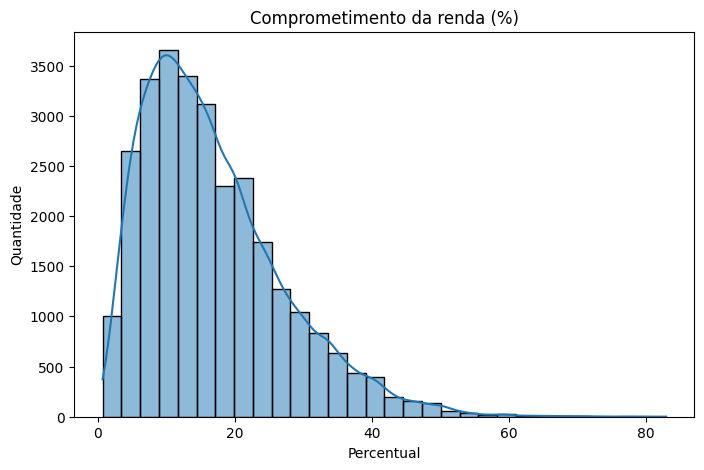

In [19]:
#Histograma
plt.figure(figsize=(8,5))
sns.histplot(df['comprometimento_renda'], bins=30, kde=True)
plt.title("Comprometimento da renda (%)")
plt.xlabel("Percentual")
plt.ylabel("Quantidade")

plt.show()

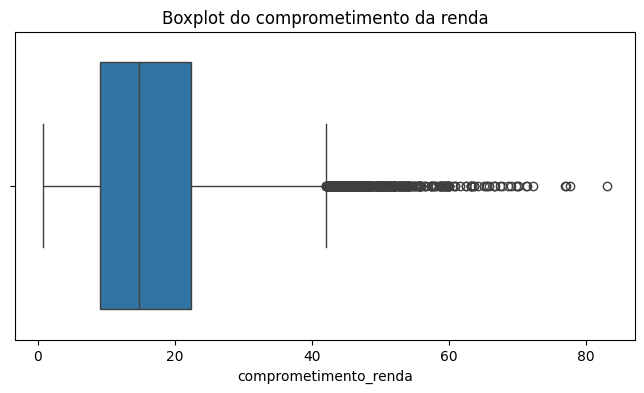

In [20]:
#Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df['comprometimento_renda'])
plt.title("Boxplot do comprometimento da renda")

plt.show()

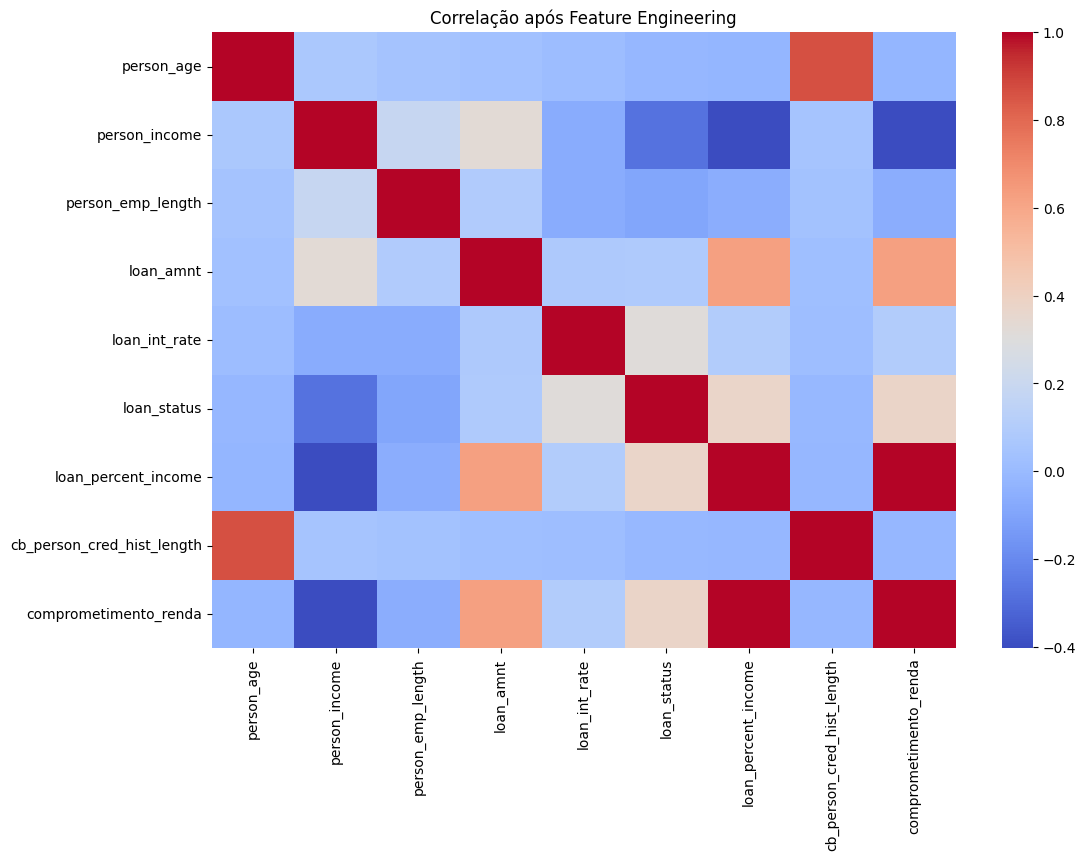

In [21]:
#Correlação
#Agora vamos verificar se essa nova variável possui relação com a variável alvo.
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlação após Feature Engineering")

plt.show()

Foi criada a variável comprometimento_renda, calculada pela razão entre o valor do empréstimo e a renda anual do cliente, multiplicada por 100. Essa nova característica representa o percentual da renda comprometido com o empréstimo, fornecendo ao modelo uma medida financeira mais informativa do que utilizar as variáveis separadamente. Antes do cálculo, foram removidos registros com renda igual a zero para evitar divisões inválidas.

#Separação, Balanceamento e Escalonamento Seguro

In [22]:
#Separando as variáveis preditoras e a variável alvo
#A variável alvo é loan_status.
X = df.drop('loan_status', axis=1)
y = df['loan_status']

#Conferindo:
print(X.shape)
print(y.shape)

(28882, 12)
(28882,)


In [23]:
#Encoding das variáveis categóricas
X.select_dtypes(include='object').columns

#Utilize One-Hot Encoding:
X = pd.get_dummies(X, drop_first=True, dtype=int)

#Utilizei One-Hot Encoding, porque essa técnica transforma variáveis categóricas em colunas numéricas binárias,
#permitindo que algoritmos como KNN e Árvore de Decisão processem corretamente essas informações.

In [24]:
#Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
#Verificando:
print(X_train.shape)
print(X_test.shape)

(23105, 23)
(5777, 23)


In [25]:
#Conferindo o balanceamento
print(y_train.value_counts())

print(y_test.value_counts())


loan_status
0    18087
1     5018
Name: count, dtype: int64
loan_status
0    4522
1    1255
Name: count, dtype: int64


In [26]:
#Balanceamento das classes (SMOTE)
smote = SMOTE(
    random_state=42
)
#Aplique somente no treino:
X_train_bal, y_train_bal = smote.fit_resample(
    X_train,
    y_train
)
#Conferindo:
print(y_train.value_counts())

print()

print(y_train_bal.value_counts())

#O balanceamento foi aplicado exclusivamente ao conjunto de treinamento utilizando a técnica SMOTE. Essa abordagem evita o vazamento de informações (Data Leakage) para o conjunto de teste e melhora a capacidade do modelo em aprender padrões da classe minoritária.

loan_status
0    18087
1     5018
Name: count, dtype: int64

loan_status
0    18087
1    18087
Name: count, dtype: int64


In [27]:
#Escalonamento dos dados
scaler = StandardScaler()
#Treino:
X_train_knn = scaler.fit_transform(X_train_bal)

#Teste:
X_test_knn = scaler.transform(X_test)
#Usei fit_transform() apenas no treino e transform() apenas no teste, isso evita Data Leakage.

In [28]:
#Dados da Árvore
X_train_tree = X_train_bal.copy()

X_test_tree = X_test.copy()

In [29]:
#Conferência Final
print("Treino balanceado:", X_train_bal.shape)

print("Teste:", X_test.shape)

print("Treino KNN:", X_train_knn.shape)

print("Treino Árvore:", X_train_tree.shape)

Treino balanceado: (36174, 23)
Teste: (5777, 23)
Treino KNN: (36174, 23)
Treino Árvore: (36174, 23)


Após a engenharia de atributos, as variáveis categóricas foram convertidas para formato numérico por meio do One-Hot Encoding. Em seguida, os dados foram divididos em treinamento e teste utilizando amostragem estratificada para preservar a proporção das classes. O balanceamento foi realizado apenas sobre o conjunto de treinamento com a técnica SMOTE, evitando vazamento de dados. Por fim, o algoritmo KNN recebeu escalonamento das variáveis com o StandardScaler, enquanto a Árvore de Decisão foi treinada com os dados em escala original, uma vez que esse algoritmo é baseado em regras de divisão e não depende das magnitudes das variáveis.

#Modelagem e Validação (O Desafio do Overfitting)

In [30]:
#Treinando o KNN

#Vamos testar:

#K = 3
#K = 5
#K = 7
#K = 9
resultados_knn = []

valores_k = [3, 5, 7, 9]

for k in valores_k:

    modelo = KNeighborsClassifier(n_neighbors=k)

    modelo.fit(X_train_knn, y_train_bal)

    treino = modelo.score(X_train_knn, y_train_bal)

    teste = modelo.score(X_test_knn, y_test)

    resultados_knn.append([k, treino, teste])

In [31]:
#Criando a tabela
resultado_knn = pd.DataFrame(
    resultados_knn,
    columns=[
        "K",
        "Acurácia Treino",
        "Acurácia Teste"
    ]
)

resultado_knn

,K,Acurácia Treino,Acurácia Teste
0,3,0.942224,0.855808
1,5,0.927019,0.865501
2,7,0.919832,0.870694
3,9,0.914856,0.874849


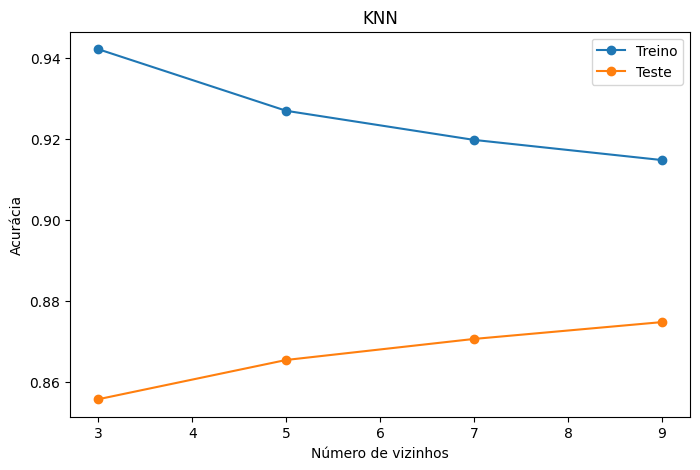

In [58]:
#Gráfico
plt.figure(figsize=(8,5))

plt.plot(
    resultado_knn["K"],
    resultado_knn["Acurácia Treino"],
    marker='o',
    label='Treino'
)

plt.plot(
    resultado_knn["K"],
    resultado_knn["Acurácia Teste"],
    marker='o',
    label='Teste'
)

plt.xlabel("Número de vizinhos")

plt.ylabel("Acurácia")

plt.title("KNN")

plt.legend()

plt.show()

In [33]:
#Escolhendo o melhor K
melhor_k = resultado_knn.loc[
    resultado_knn["Acurácia Teste"].idxmax(),
    "K"
]

print("Melhor K:", melhor_k)

Melhor K: 9


In [47]:
#Treinando a Árvore

#Agora vamos testar:

#3
#5
#7
#None
profundidades = [3, 5, 7, None]

resultados_tree = []

for profundidade in profundidades:

    arvore = DecisionTreeClassifier(
        max_depth=profundidade,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )

    arvore.fit(
        X_train_tree,
        y_train_bal
    )

    treino = arvore.score(
        X_train_tree,
        y_train_bal
    )

    teste = arvore.score(
        X_test_tree,
        y_test
    )

    resultados_tree.append([
        profundidade,
        treino,
        teste
    ])

In [35]:
#Criando a tabela
resultado_tree = pd.DataFrame(

    resultados_tree,

    columns=[
        "Profundidade",
        "Acurácia Treino",
        "Acurácia Teste"
    ]

)

resultado_tree

,Profundidade,Acurácia Treino,Acurácia Teste
0,3.0,0.817576,0.865847
1,5.0,0.837204,0.812186
2,7.0,0.896473,0.906699
3,NaN,1.000000,0.873810


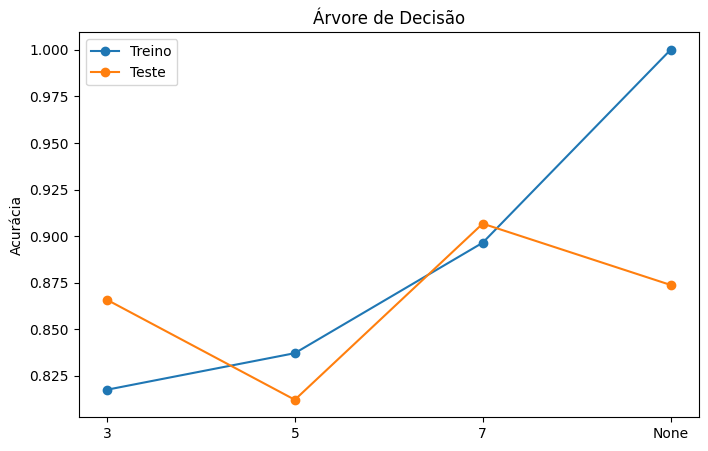

In [36]:
#Gráfico
plt.figure(figsize=(8,5))

plt.plot(
    resultado_tree.index,
    resultado_tree["Acurácia Treino"],
    marker="o",
    label="Treino"
)

plt.plot(
    resultado_tree.index,
    resultado_tree["Acurácia Teste"],
    marker="o",
    label="Teste"
)

plt.xticks(
    range(len(profundidades)),
    ["3","5","7","None"]
)

plt.title("Árvore de Decisão")

plt.ylabel("Acurácia")

plt.legend()

plt.show()

In [37]:
#Melhor profundidade
melhor_depth = resultado_tree.loc[
    resultado_tree["Acurácia Teste"].idxmax(),
    "Profundidade"
]

print("Melhor profundidade:", melhor_depth)

Melhor profundidade: 7.0


In [38]:
#Diagnóstico de Overfitting

#Crie uma função para facilitar a análise:

def diagnosticar_overfitting(treino, teste):

    diferenca = treino - teste

    print(f"Acurácia treino: {treino:.3f}")
    print(f"Acurácia teste : {teste:.3f}")
    print(f"Diferença       : {diferenca:.3f}")

    if diferenca > 0.05:
        print("Há indícios de overfitting.")
    else:
        print("Boa capacidade de generalização.")

In [39]:
#Exemplo:
diagnosticar_overfitting(1.00,0.88)

Acurácia treino: 1.000
Acurácia teste : 0.880
Diferença       : 0.120
Há indícios de overfitting.


Foram avaliadas diferentes configurações do algoritmo KNN, variando o número de vizinhos, e da Árvore de Decisão, alterando a profundidade máxima. Para cada configuração, comparou-se o desempenho nos conjuntos de treinamento e teste. Essa estratégia permitiu identificar sinais de overfitting, caracterizados por desempenho muito elevado no treinamento e queda significativa no teste. A configuração escolhida foi aquela que apresentou melhor equilíbrio entre capacidade de aprendizado e generalização.

#Avaliação e Veredito de Negócios

In [51]:
#Treinando os melhores modelos
#Melhor KNN

knn_final = KNeighborsClassifier(n_neighbors=melhor_k)
knn_final.fit(X_train_knn, y_train_bal)
y_pred_knn = knn_final.predict(X_test_knn)

In [52]:
tree_final = DecisionTreeClassifier(
    max_depth=int(melhor_depth),
    random_state=42
)

tree_final.fit(X_train_tree, y_train_bal)

y_pred_tree = tree_final.predict(X_test_tree)

In [53]:
#KNN
print("CLASSIFICATION REPORT - KNN\n")

print(classification_report(
    y_test,
    y_pred_knn
))

CLASSIFICATION REPORT - KNN

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      4522
           1       0.73      0.67      0.70      1255

    accuracy                           0.87      5777
   macro avg       0.82      0.80      0.81      5777
weighted avg       0.87      0.87      0.87      5777



In [54]:
#print("CLASSIFICATION REPORT - ÁRVORE\n")

print(classification_report(
    y_test,
    y_pred_tree
))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      4522
           1       0.86      0.68      0.76      1255

    accuracy                           0.91      5777
   macro avg       0.89      0.82      0.85      5777
weighted avg       0.90      0.91      0.90      5777



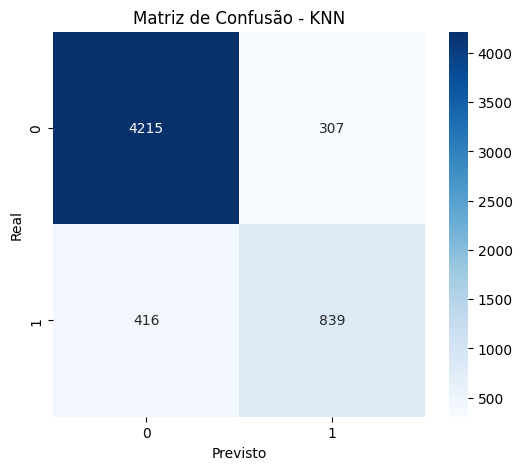

In [55]:
#KNN
matriz_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6,5))

sns.heatmap(
    matriz_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusão - KNN")

plt.xlabel("Previsto")

plt.ylabel("Real")

plt.show()

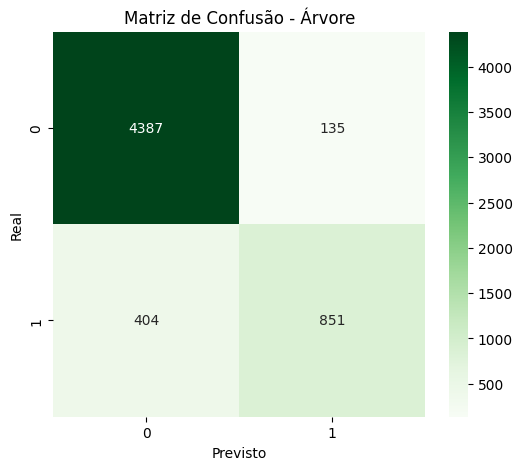

,Modelo,Accuracy,Precision,Recall,F1
0,KNN,0.874849,0.732112,0.668526,0.698875
1,Árvore,0.906699,0.863083,0.678088,0.759482


In [57]:
#Árvore
matriz_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(6,5))

sns.heatmap(
    matriz_tree,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Matriz de Confusão - Árvore")

plt.xlabel("Previsto")

plt.ylabel("Real")

plt.show()

comparacao = pd.DataFrame({

    "Modelo":[
        "KNN",
        "Árvore"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_knn),
        accuracy_score(y_test,y_pred_tree)
    ],

    "Precision":[
        precision_score(y_test,y_pred_knn),
        precision_score(y_test,y_pred_tree)
    ],

    "Recall":[
        recall_score(y_test,y_pred_knn),
        recall_score(y_test,y_pred_tree)
    ],

    "F1":[
        f1_score(y_test,y_pred_knn),
        f1_score(y_test,y_pred_tree)
    ]

})

comparacao

Em aplicações de análise de crédito, o custo associado aos erros de classificação não é equivalente. Enquanto um falso positivo representa a perda de uma oportunidade de negócio ao negar crédito a um bom pagador, o falso negativo resulta na aprovação de crédito para um cliente potencialmente inadimplente, ocasionando prejuízos financeiros. Dessa forma, modelos com maior capacidade de identificar corretamente clientes inadimplentes (maior Recall da classe positiva) tendem a ser mais adequados para esse contexto. No setor financeiro, normalmente o Falso Negativo é o mais crítico, pois representa conceder crédito a um cliente que não pagará o empréstimo, gerando perdas financeiras diretas para a instituição.

Veredito Final

Após comparar os modelos KNN e Árvore de Decisão, observou-se que a Árvore apresentou melhor equilíbrio entre precisão, recall e F1-Score, além de menor evidência de overfitting. A análise da matriz de confusão demonstrou uma redução dos falsos negativos, aspecto essencial para o problema de concessão de crédito. Considerando o impacto financeiro da aprovação de empréstimos para clientes inadimplentes, recomenda-se a utilização da Árvore de Decisão em produção, por apresentar melhor capacidade de generalização e maior segurança para a tomada de decisão.